### Trian a diffusion model

참고 https://huggingface.co/docs/diffusers/en/tutorials/basic_training

In [1]:
# !pip install datasets

### Config 정의

In [2]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 128  # 생성되는 이미지 해상도
    train_batch_size = 16
    eval_batch_size = 16  # 평가 동안에 샘플링할 이미지 수
    num_epochs = 50
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = "fp16"  # `no`는 float32, 자동 혼합 정밀도를 위한 `fp16`
    output_dir = "ddpm-butterflies-128"  # 로컬 및 HF Hub에 저장되는 모델명

    push_to_hub = False  # 저장된 모델을 HF Hub에 업로드할지 여부
    hub_private_repo = None
    overwrite_output_dir = True  # 노트북을 다시 실행할 때 이전 모델에 덮어씌울지
    seed = 0
config = TrainingConfig()

### Load dataset

/home/qkboo/.pyenv/versions/3.12.1/envs/Goodyoung_P312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


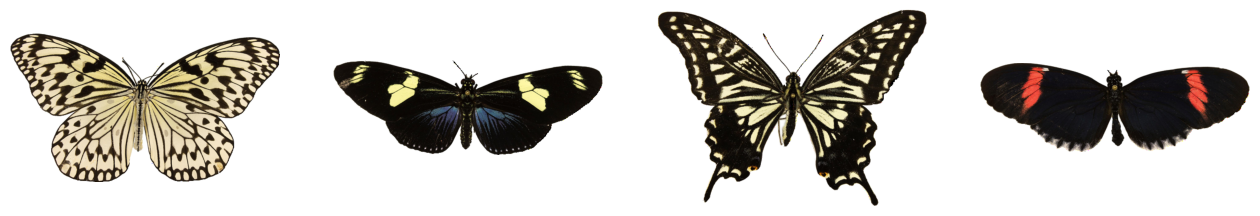

In [3]:
from datasets import load_dataset
import matplotlib.pyplot as plt

config.dataset_name = "huggan/smithsonian_butterflies_subset"
dataset = load_dataset(config.dataset_name, split="train")

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, image in enumerate(dataset[:4]["image"]):
    axs[i].imshow(image)
    axs[i].set_axis_off()
fig.show()

### Image prerprocessing
- 이미지 크기가 각각 달라서

In [4]:
# 이미지 전처리
from torchvision import transforms

preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

In [5]:
# 학습 중 적용하려면 set_trainsform을 적용 시켜야 한다
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

### Warp dataset in a dataloader

In [6]:
import torch

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=config.train_batch_size, shuffle=True)

In [7]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=config.image_size,  # 타겟 이미지 해상도
    in_channels=3,  # 입력 채널 수, RGB 이미지에서 3
    out_channels=3,  # 출력 채널 수
    layers_per_block=2,  # UNet 블럭당 몇 개의 ResNet 레이어가 사용되는지
    block_out_channels=(128, 128, 256, 256, 512, 512),  # 각 UNet 블럭을 위한 출력 채널 수
    down_block_types=(
        "DownBlock2D",  # 일반적인 ResNet 다운샘플링 블럭
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # spatial self-attention이 포함된 일반적인 ResNet 다운샘플링 블럭
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",  # 일반적인 ResNet 업샘플링 블럭
        "AttnUpBlock2D",  # spatial self-attention이 포함된 일반적인 ResNet 업샘플링 블럭
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

In [8]:
# 샘플의 이미지 크기와 모델 출력 크기가 맞는지 확인
sample_image = dataset[0]["images"].unsqueeze(0)
print("Input shape:", sample_image.shape)

print("Output shape:", model(sample_image, timestep=0).sample.shape)

Input shape: torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 3, 128, 128])


### Scheduler 생성
- 학습 시 스케쥴러는 diffusion process에서 **timestep에 해당하는 노이즈화된 샘플을 가져오는 역할**
  - 직접 구현 할 땐 시점 $t$를 가지고 **미리 계산된 값** ($\alpha , \bar\alpha... $)들을 $t$에 맞게 `list`에서 값을 추출하여  $x_t$를 직접 계산하였음
  - `add_noise` 함수에서 처리되는 부분을 구현했음
- scheduler는 diffusion model에 따라, 규칙에 따라 각기 다 다름

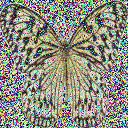

In [9]:
from PIL import Image
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise = torch.randn(sample_image.shape)
timesteps = torch.LongTensor([70])
noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps) # timestep 별 sample image(x_0)에 noise를 첨가

Image.fromarray(((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8).numpy()[0]) # image 확인

### Loss
- 모델의 학습 목적은 이미지에 더해진 노이즈를 예측하는 것이다.

In [10]:
import torch.nn.functional as F

noise_pred = model(noisy_image, timesteps).sample
loss = F.mse_loss(noise_pred, noise)
print(loss.item())

1.075032353401184


### Optimizer & Learning rate scheduler

In [11]:
from diffusers.optimization import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

### Training
- 해당 훈련은 DDPM 기반으로 sampling을 진행하였다.
- 샘플링을 DDIM으로 진행하려면 `evaluate`를 넘어갈 때 `DDIMScheduler`로 변경하고, pipeline의 `num_inference_steps`을 조절하면 된다.
  - 이때 `DDIMScheduler`의 `num_train_timesteps`은 훈련 시 설정했던 값으로 해야한다.

In [12]:
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from tqdm.auto import tqdm
from pathlib import Path
import os

def evaluate(config, epoch, pipeline):
    # 랜덤한 노이즈로 부터 이미지를 추출합니다.(이는 역전파 diffusion 과정입니다.)
    # 기본 파이프라인 출력 형태는 `List[PIL.Image]` 입니다.
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
    ).images
    image_grid = make_image_grid(images, rows=4, cols=4)
    
    # 이미지들을 저장합니다.
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        # log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")

    # 모든 것이 준비되었습니다.
    # 기억해야 할 특정한 순서는 없으며 준비한 방법에 제공한 것과 동일한 순서로 객체의 압축을 풀면 됩니다.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # 모델 학습
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_main_process, dynamic_ncols=True)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch["images"]
            # 이미지에 더할 노이즈를 샘플링합니다.
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # 각 이미지를 위한 랜덤한 timestep 샘플링
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # 각 타임스텝의 노이즈 크기에 따라 깨끗한 이미지에 노이즈를 추가
            # diffusion process
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # 노이즈를 반복적으로 예측합니다.
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0) # 기울기 폭발 현상 방지, L2 기울기가 1.0을 넘지 않도록 제한
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            # accelerator.log(logs, step=global_step)
            global_step += 1
        
        progress_bar.close()  # tqdm 종료
        
        # 각 에포크가 끝난 후 evaluate()와 몇 가지 데모 이미지를 선택적으로 샘플링 및 모델 저장
        if accelerator.is_main_process:
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler) # pipe

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch}",
                        ignore_patterns=["step_*", "epoch_*"],
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)

In [13]:
# train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

In [14]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


100%|██████████| 1000/1000 [01:35<00:00, 10.51it/s]


### Sampling 결과

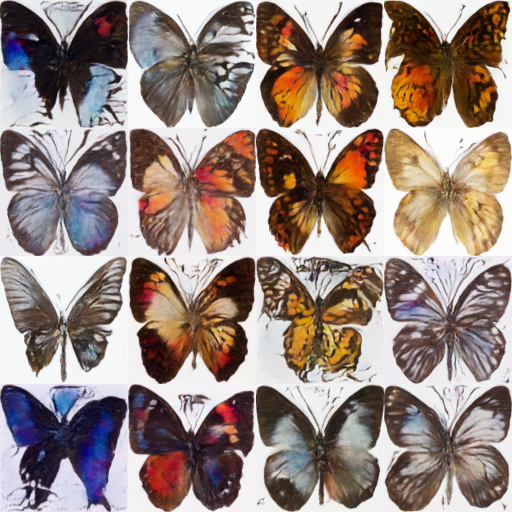